# prerequisite

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install pydot graphviz


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

# EDA

In [28]:
df = pd.read_csv("../Data/titanic.csv")
print(f"Shape of dataset: {df.shape}")
display(df.head())

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


value counts of Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipython-input-3856776410.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




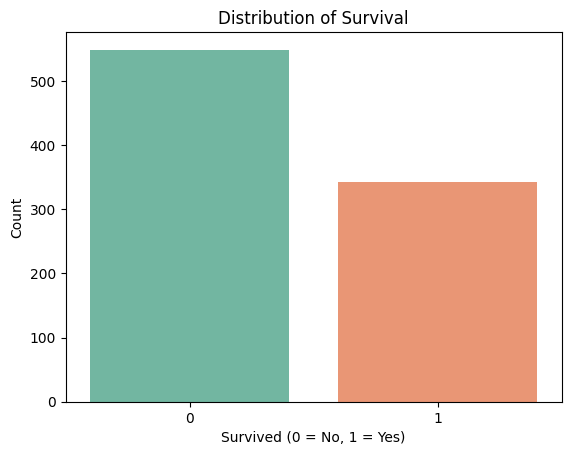

In [29]:
print(f'value counts of {df.Survived.value_counts()}')

sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Distribution of Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
df.shape

(891, 12)

In [32]:
df.isnull().sum() / len(df) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [33]:
object_col = df.select_dtypes(include="object").columns
object_col

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [34]:
for col in object_col:
    print(f'column : {col}')
    print(f'len of unique data : {len(df[col].unique())}')
    print(f'value counts of data:\n{df[col].value_counts()}')
    print('-'*20)

column : Name
len of unique data : 891
value counts of data:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64
--------------------
column : Sex
len of unique data : 2
value counts of data:
Sex
male      577
female    314
Name: count, dtype: int64
--------------------
column : Ticket
len of unique data : 681
value counts of data:
Ticket
347082              7
1601              

# Preprocessing

In [21]:
df.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1, inplace=True)

In [47]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

print(f"lower bound: {lower_bound}, upper bound: {upper_bound}")
print(f"minimum data in Age: {df['Age'].min()} maximum data in Age: {df['Age'].max()}")

df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

print(f"Number of primary data (without null values): {df['Age'].count()}")
print(f"Number of data after removing outliers (without null values): {len(df_no_outliers)}")

lower bound: -33.5, upper bound: 91.625
minimum data in Age: 0.42 maximum data in Age: 80.0
Number of primary data (without null values): 714
Number of data after removing outliers (without null values): 714


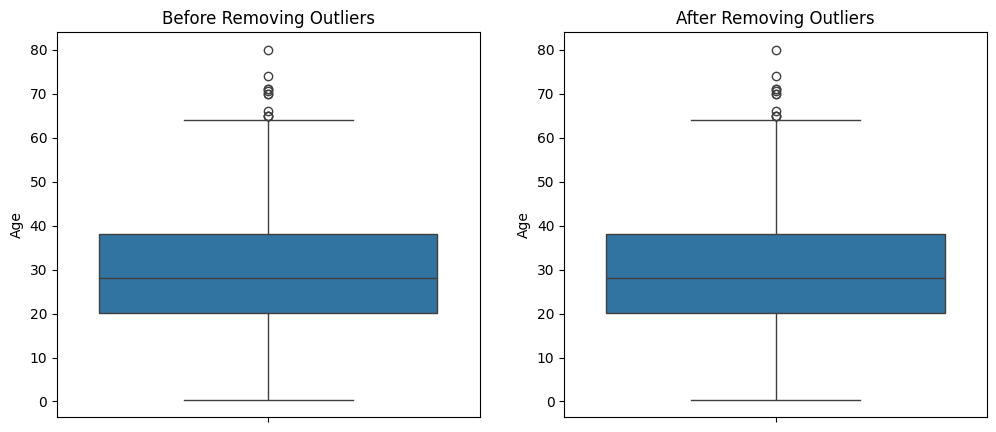

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Age'], ax=axes[0])
axes[0].set_title("Before Removing Outliers")

sns.boxplot(y=df_no_outliers['Age'], ax=axes[1])
axes[1].set_title("After Removing Outliers")
plt.show()


In [24]:
df_no_outliers['Embarked'].mode()[0]

'S'

In [25]:
df_no_outliers['Embarked'].fillna(df_no_outliers['Embarked'].mode()[0], inplace=True)
df_no_outliers['Age'].fillna(df_no_outliers['Age'].median(), inplace=True)

/tmp/ipython-input-3355001671.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-3355001671.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3355001671.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior w

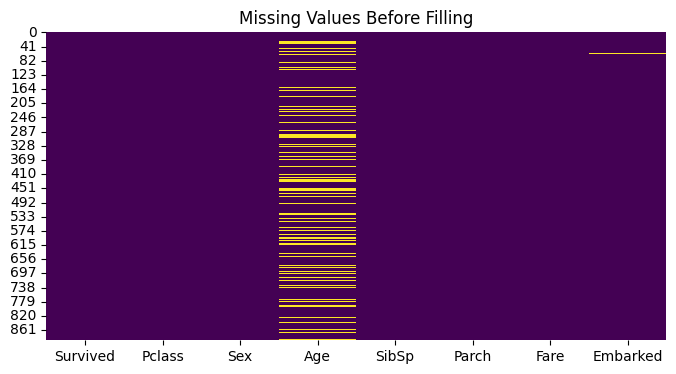

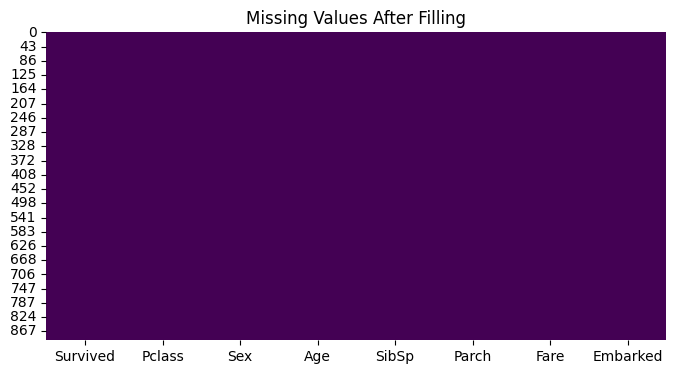

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Before Filling")
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(df_no_outliers.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values After Filling")
plt.show()

In [ ]:
print(f"len of unique data : {len(df_no_outliers['Embarked'].unique())}")
print(f"value counts of data:\n{df_no_outliers['Embarked'].value_counts()}")

len of unique data : 3
value counts of data:
Embarked
S    556
C    130
Q     28
Name: count, dtype: int64


In [ ]:
df_no_outliers.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
temp = pd.get_dummies(df_no_outliers['Embarked']).astype('int64')
new_df = pd.concat([df_no_outliers, temp], axis=1)
new_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,C,Q,S
0,0,3,male,22.0,1,0,7.2500,S,0,0,1
1,1,1,female,38.0,1,0,71.2833,C,1,0,0
2,1,3,female,26.0,0,0,7.9250,S,0,0,1
3,1,1,female,35.0,1,0,53.1000,S,0,0,1
4,0,3,male,35.0,0,0,8.0500,S,0,0,1


In [ ]:
new_df.drop('Embarked', axis=1, inplace=True)

In [ ]:
new_df.Sex.replace({'male':1, 'female':0}, inplace=True)
new_df.head()

/tmp/ipykernel_67468/1528791473.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df.Sex.replace({'male':1, 'female':0}, inplace=True)
/tmp/ipykernel_67468/1528791473.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df.Sex.replace({'male':1, 'female':0}, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [ ]:
new_df.Survived.value_counts()

Survived
0    424
1    290
Name: count, dtype: int64

In [ ]:
X = new_df.drop("Survived", axis=1)
y = new_df["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=32)

print(f'shape of x_train: {x_train.shape}')
print(f'shape of y_train: {y_train.shape}')
print(f'shape of x_test: {x_test.shape}')
print(f'shape of y_test: {y_test.shape}')

shape of x_train: (642, 9)
shape of y_train: (642,)
shape of x_test: (72, 9)
shape of y_test: (72,)


In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

x_train_scaled = std.fit_transform(x_train)
x_test_scaled = std.transform(x_test)

# Design The Model

In [ ]:
import keras
from keras import layers

model = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


2025-08-13 17:18:47.032743: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 17:18:47.103586: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 17:18:47.184878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755092927.240588   67468 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755092927.259938   67468 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755092927.355432   67468 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421 (1.64 KB)

 Trainable params: 421 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

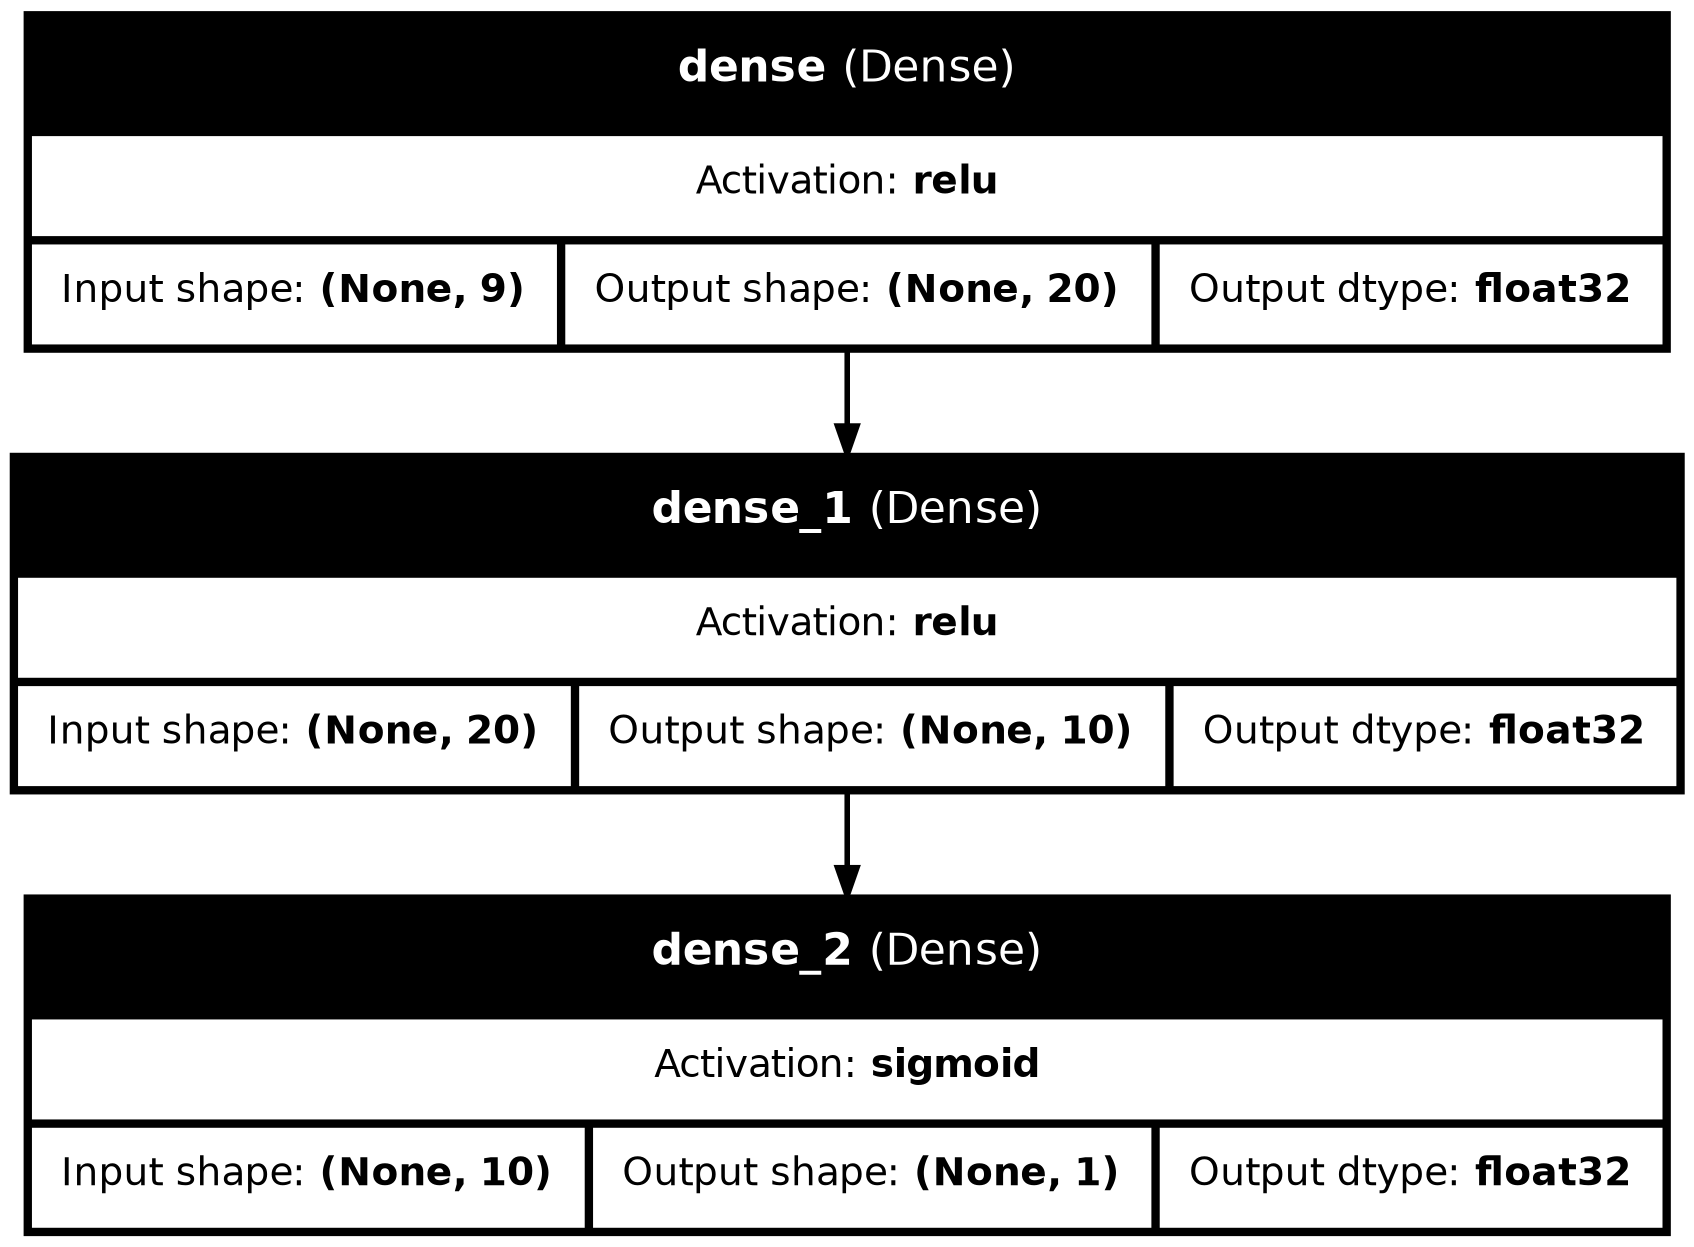

In [ ]:
keras.utils.plot_model(model, to_file='model.png',
                       show_shapes=True, show_dtype=True,
                       show_layer_activations=True, show_layer_names=True)

In [ ]:
model.fit(x_train_scaled, y_train, epochs=20, validation_split=0.1)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6343 - loss: 0.6803 - val_accuracy: 0.6462 - val_loss: 0.6710
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6620 - loss: 0.6463 - val_accuracy: 0.6462 - val_loss: 0.6432
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6863 - loss: 0.6223 - val_accuracy: 0.7077 - val_loss: 0.6168
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7244 - loss: 0.6006 - val_accuracy: 0.6769 - val_loss: 0.5917
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7452 - loss: 0.5786 - val_accuracy: 0.6923 - val_loss: 0.5700
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7591 - loss: 0.5580 - val_accuracy: 0.7231 - val_loss: 0.5493
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7764 - loss: 0.5387 - val_accuracy: 0.7692 - val_loss: 0.5253
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7886 - loss: 0.5234 - val_accuracy: 0.7846 - va

In [ ]:
y_test_pre = np.where(model.predict(x_test) > 0.5, 1, 0)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
from sklearn.metrics import accuracy_score
print(f'accuracy score of test data : {accuracy_score(y_test, y_test_pre)}')

accuracy score of test data : 0.6944444444444444
